In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from textblob import TextBlob
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PRATEEKK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv("brand_analysis_dataset.csv")

In [3]:
print(df.head())
print(df.info())

   post_id    brand   user_type  \
0        1   Adidas     student   
1        2   Adidas     athlete   
2        3     Puma     athlete   
3        4  Samsung  influencer   
4        5    Apple  influencer   

                                           post_text  likes  comments  shares  
0  Adidas It's okay, average product nothing special    353        13     147  
1          Adidas Decent experience, could be better    935       216      92  
2      Puma Worst purchase ever, would not recommend    958        32      71  
3  Samsung Great experience, highly recommend thi...     72        41     125  
4     Apple Worst purchase ever, would not recommend    222       178      34  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   post_id    3000 non-null   int64 
 1   brand      3000 non-null   object
 2   user_type  3000 non-null   object
 3   pos

In [4]:
df = df.dropna()
df = df.drop_duplicates()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df['clean_text'] = df['post_text'].apply(clean_text)

In [5]:
brand_df = df[df['brand'] == "Nike"]  

**PART 1: SENTIMENT ANALYSIS**

In [6]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

brand_df['polarity'] = brand_df['clean_text'].apply(get_sentiment)

def classify(p):
    if p > 0:
        return "positive"
    elif p < 0:
        return "negative"
    else:
        return "neutral"

brand_df['sentiment'] = brand_df['polarity'].apply(classify)

C:\Users\PRATEEKK\AppData\Local\Temp\ipykernel_20560\1361550267.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['polarity'] = brand_df['clean_text'].apply(get_sentiment)
C:\Users\PRATEEKK\AppData\Local\Temp\ipykernel_20560\1361550267.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['sentiment'] = brand_df['polarity'].apply(classify)


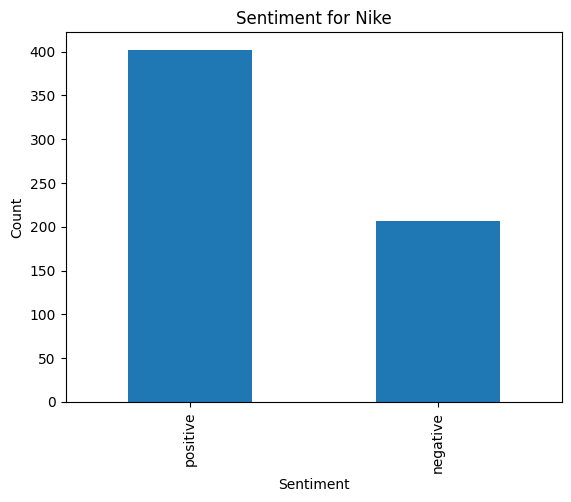

In [7]:
brand_df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment for Nike")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

**PART 2: KEYWORD ANALYSIS**

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', max_features=10)
X = cv.fit_transform(brand_df['clean_text'])

print(cv.get_feature_names_out())

['bad' 'disappointed' 'experience' 'great' 'nike' 'poor' 'product'
 'quality' 'recommend' 'worth']


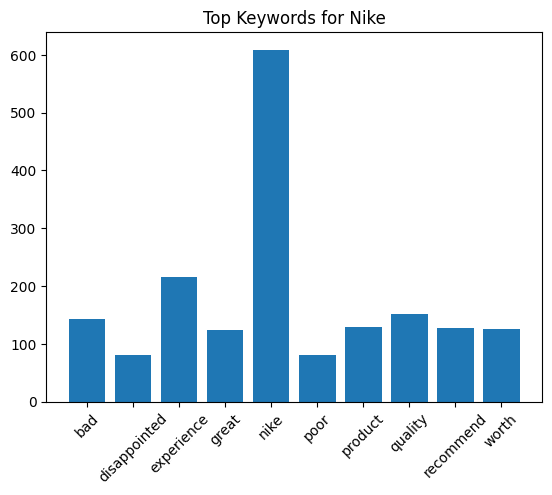

In [11]:
counts = X.toarray().sum(axis=0)
plt.bar(cv.get_feature_names_out(), counts)
plt.xticks(rotation=45)
plt.title("Top Keywords for Nike")
plt.show()

**PART 3: ENGAGEMENT ANALYSIS**

In [12]:
brand_df['engagement'] = brand_df['likes'] + brand_df['comments'] + brand_df['shares']

print("Average Engagement:", brand_df['engagement'].mean())

top_post = brand_df.loc[brand_df['engagement'].idxmax()]
print(top_post)

Average Engagement: 785.1707717569786
post_id                                                2758
brand                                                  Nike
user_type                                        influencer
post_text     Nike Worst purchase ever, would not recommend
likes                                                   992
comments                                                285
shares                                                  157
clean_text     nike worst purchase ever would not recommend
polarity                                               -1.0
sentiment                                          negative
engagement                                             1434
Name: 2757, dtype: object


C:\Users\PRATEEKK\AppData\Local\Temp\ipykernel_20560\3726223928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['engagement'] = brand_df['likes'] + brand_df['comments'] + brand_df['shares']


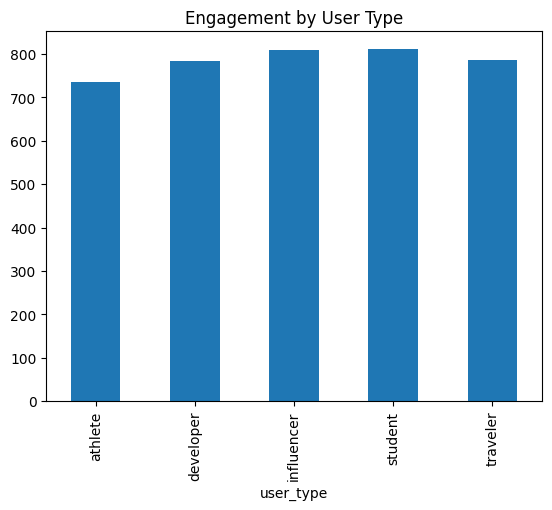

In [13]:
brand_df.groupby('user_type')['engagement'].mean().plot(kind='bar')

plt.title("Engagement by User Type")
plt.show()